# CodeAlpha Data Analytics Internship
# TASK 3: Data Visualization
# Dataset: Titanic (via seaborn built-in)
# Author: Aisha Arif

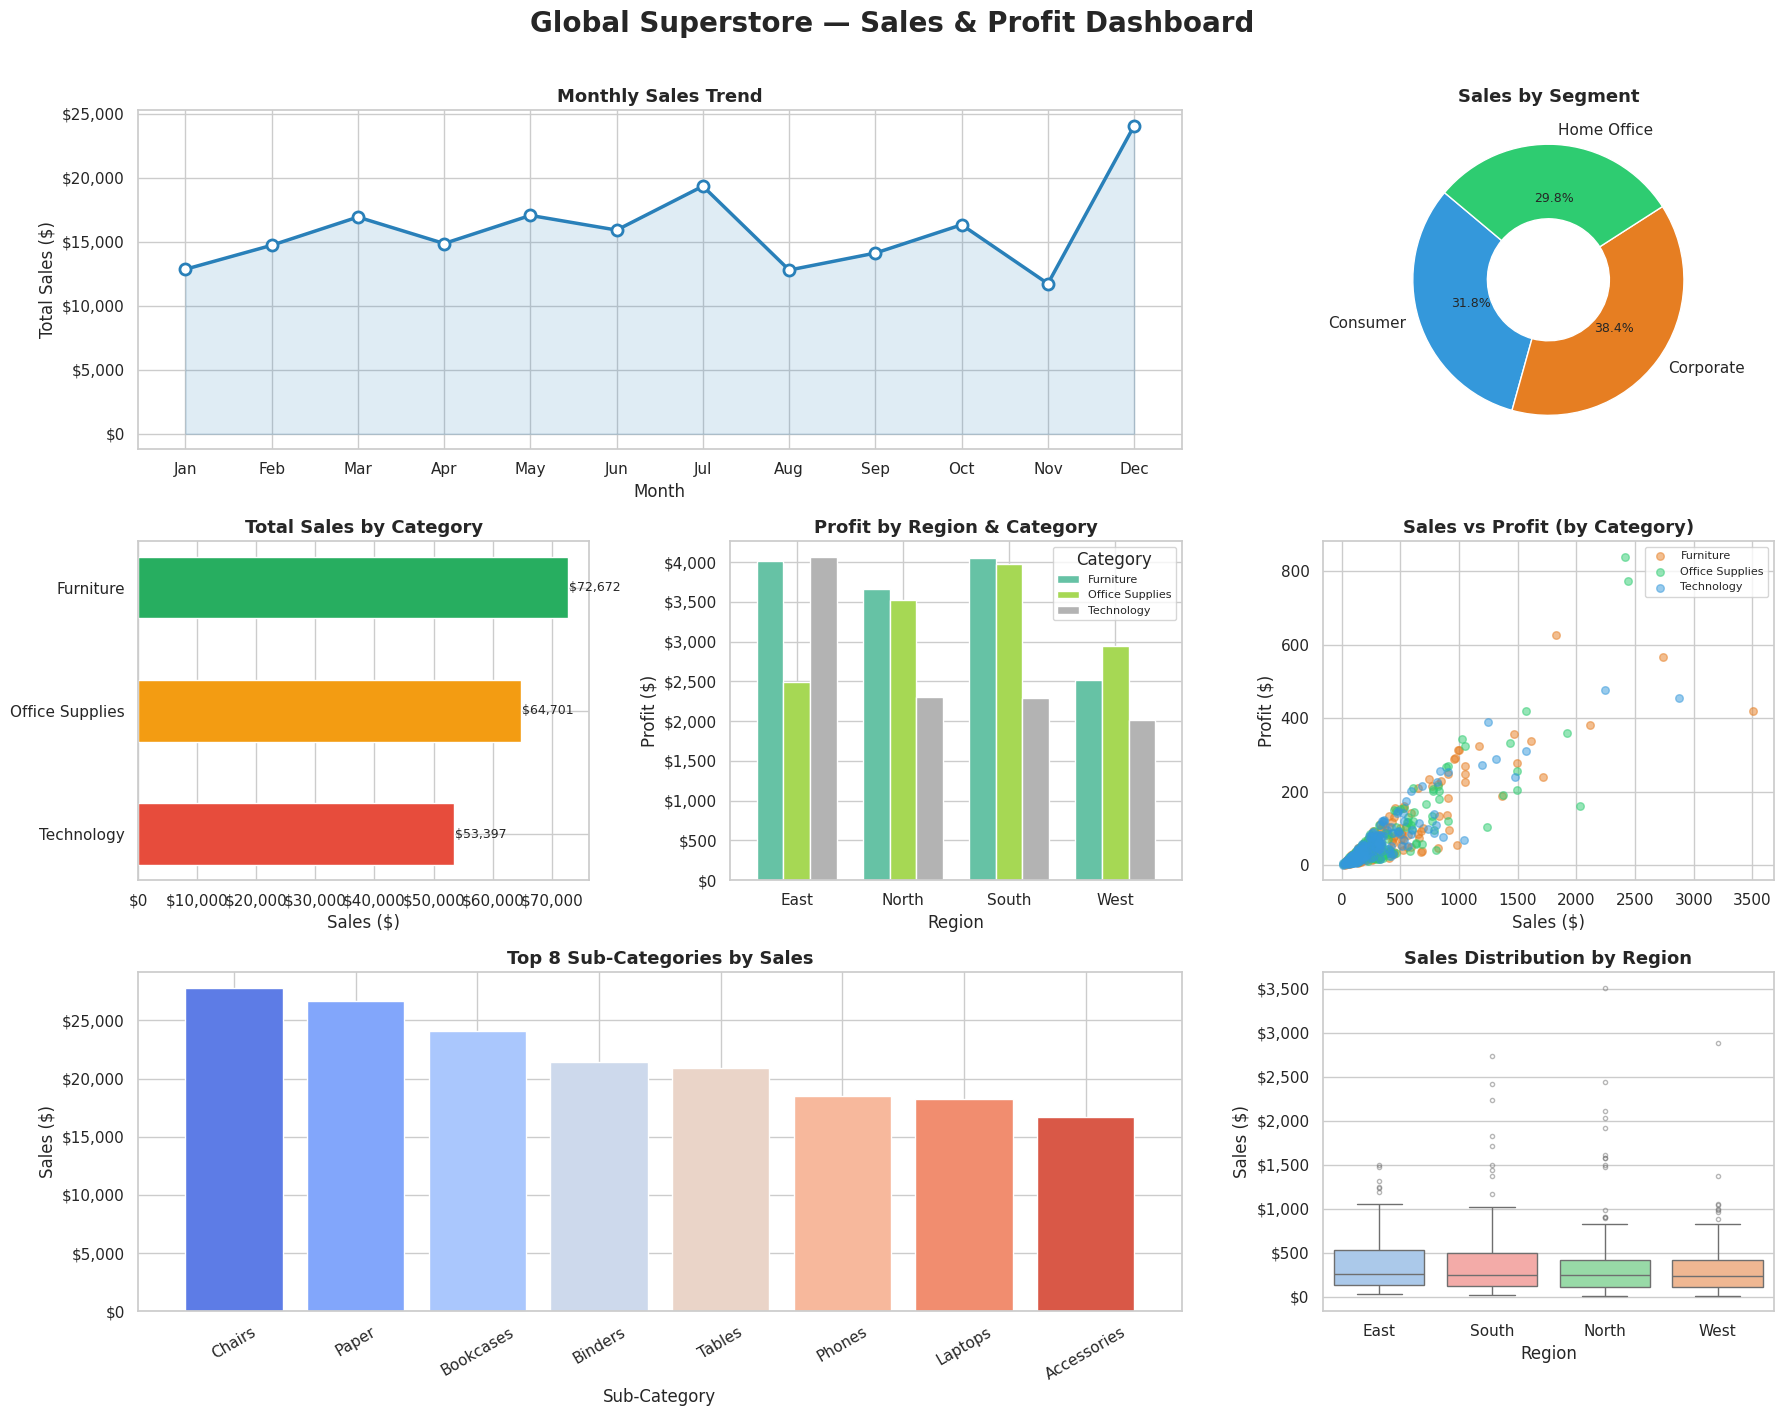

 Dashboard saved as 'sales_dashboard.png'.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# 1. Generate Realistic Synthetic Sales Dataset
np.random.seed(42)
n = 500

categories    = ['Technology', 'Furniture', 'Office Supplies']
sub_cats      = {
    'Technology'     : ['Phones', 'Laptops', 'Accessories'],
    'Furniture'      : ['Chairs', 'Tables', 'Bookcases'],
    'Office Supplies': ['Binders', 'Paper', 'Pens'],
}
regions       = ['North', 'South', 'East', 'West']
segments      = ['Consumer', 'Corporate', 'Home Office']
months        = pd.date_range('2023-01-01', periods=12, freq='MS')

cat_choice    = np.random.choice(categories, n)
sub_cat_list  = [np.random.choice(sub_cats[c]) for c in cat_choice]
region_choice = np.random.choice(regions, n)
seg_choice    = np.random.choice(segments, n)
month_choice  = np.random.choice(months, n)

sales         = np.random.lognormal(mean=5.5, sigma=1.0, size=n).round(2)
profit        = (sales * np.random.uniform(0.05, 0.35, n)).round(2)
quantity      = np.random.randint(1, 20, n)

df = pd.DataFrame({
    'Month'      : month_choice,
    'Category'   : cat_choice,
    'Sub_Category': sub_cat_list,
    'Region'     : region_choice,
    'Segment'    : seg_choice,
    'Sales'      : sales,
    'Profit'     : profit,
    'Quantity'   : quantity,
})
df['Month_Label'] = df['Month'].dt.strftime('%b')
df['Month_Num']   = df['Month'].dt.month

# 2. Aggregations
monthly_sales  = df.groupby('Month_Num')['Sales'].sum().reset_index()
monthly_sales['Month_Label'] = pd.to_datetime(
    monthly_sales['Month_Num'], format='%m').dt.strftime('%b')

category_sales = df.groupby('Category')['Sales'].sum().sort_values()
region_profit  = df.groupby('Region')['Profit'].sum()
sub_sales      = (df.groupby('Sub_Category')['Sales']
                    .sum().sort_values(ascending=False).head(8))
seg_sales      = df.groupby('Segment')['Sales'].sum()

# 3. Dashboard Layout
sns.set_theme(style='whitegrid', palette='Set2')
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Global Superstore — Sales & Profit Dashboard",
             fontsize=20, fontweight='bold', y=1.01)

# Chart 1: Monthly Sales Trend (Line)
ax1 = fig.add_subplot(3, 3, (1, 2))          # spans 2 columns
ax1.plot(monthly_sales['Month_Label'],
         monthly_sales['Sales'],
         marker='o', linewidth=2.5,
         color='#2980b9', markerfacecolor='white',
         markeredgewidth=2, markersize=8)
ax1.fill_between(monthly_sales['Month_Label'],
                 monthly_sales['Sales'], alpha=0.15, color='#2980b9')
ax1.set_title("Monthly Sales Trend", fontsize=13, fontweight='bold')
ax1.set_xlabel("Month"); ax1.set_ylabel("Total Sales ($)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}"))

# Chart 2: Donut — Sales by Segment
ax2 = fig.add_subplot(3, 3, 3)
colors_donut = ['#3498db', '#e67e22', '#2ecc71']
wedges, texts, autotexts = ax2.pie(
    seg_sales, labels=seg_sales.index,
    autopct='%1.1f%%', startangle=140,
    colors=colors_donut,
    wedgeprops=dict(width=0.55, edgecolor='white'))
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title("Sales by Segment", fontsize=13, fontweight='bold')

# Chart 3: Horizontal Bar — Sales by Category
ax3 = fig.add_subplot(3, 3, 4)
bars = ax3.barh(category_sales.index, category_sales.values,
                color=['#e74c3c', '#f39c12', '#27ae60'],
                edgecolor='white', height=0.5)
for bar in bars:
    ax3.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
             f"${bar.get_width():,.0f}", va='center', fontsize=9)
ax3.set_title("Total Sales by Category", fontsize=13, fontweight='bold')
ax3.set_xlabel("Sales ($)")
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}"))

# Chart 4: Grouped Bar — Profit by Region
ax4 = fig.add_subplot(3, 3, 5)
region_profit_df = (df.groupby(['Region', 'Category'])['Profit']
                      .sum().unstack())
region_profit_df.plot(kind='bar', ax=ax4, edgecolor='white',
                      colormap='Set2', width=0.75)
ax4.set_title("Profit by Region & Category",
              fontsize=13, fontweight='bold')
ax4.set_xlabel("Region"); ax4.set_ylabel("Profit ($)")
ax4.tick_params(axis='x', rotation=0)
ax4.legend(title='Category', fontsize=8)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}"))

# Chart 5: Scatter — Sales vs Profit
ax5 = fig.add_subplot(3, 3, 6)
palette_map = {'Technology': '#3498db',
               'Furniture': '#e67e22',
               'Office Supplies': '#2ecc71'}
for cat, grp in df.groupby('Category'):
    ax5.scatter(grp['Sales'], grp['Profit'],
                alpha=0.5, s=30, label=cat,
                color=palette_map[cat])
ax5.set_title("Sales vs Profit (by Category)",
              fontsize=13, fontweight='bold')
ax5.set_xlabel("Sales ($)"); ax5.set_ylabel("Profit ($)")
ax5.legend(fontsize=8)

# Chart 6: Top 8 Sub-Categories (Bar)
ax6 = fig.add_subplot(3, 3, (7, 8))
colors_sub = sns.color_palette("coolwarm", len(sub_sales))
ax6.bar(sub_sales.index, sub_sales.values,
        color=colors_sub, edgecolor='white')
ax6.set_title("Top 8 Sub-Categories by Sales",
              fontsize=13, fontweight='bold')
ax6.set_xlabel("Sub-Category"); ax6.set_ylabel("Sales ($)")
ax6.tick_params(axis='x', rotation=30)
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}"))

# Chart 7: Box Plot — Sales Distribution by Region
ax7 = fig.add_subplot(3, 3, 9)
region_order = df.groupby('Region')['Sales'].median().sort_values(
    ascending=False).index.tolist()
sns.boxplot(data=df, x='Region', y='Sales',hue='Region', order=region_order,
            palette='pastel', ax=ax7, legend=False,
            flierprops=dict(marker='o', markersize=3, alpha=0.5))
ax7.set_title("Sales Distribution by Region",
              fontsize=13, fontweight='bold')
ax7.set_xlabel("Region"); ax7.set_ylabel("Sales ($)")
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("sales_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Dashboard saved as 'sales_dashboard.png'.")